Data source: https://data.humdata.org/dataset/international-migration-flows

# Synthetic control (SCM) 
- **CL**:
    - December 2020:  
The Chilean Constitutional Court reviewed and approved the final version after challenges to several articles.
    - 11 April 2021:  
President Piñera officially promulgated the law.
    - 20 April 2021:  
The law was published in the Diario Oficial.

In [1]:
import io
import numpy as np
import pandas as pd
from tqdm import tqdm
import geopandas as gpd
from pathlib import Path
from itertools import permutations

# Visualisation
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
matplotlib.rcParams['font.family'] = 'DejaVu Sans'  # has wide Unicode support

# Model
import cvxpy as cp
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Base directories
BASE_DIR = Path("/Users/wenlanzhang/PycharmProjects/Mapineq/src/")
DATA_DIR = Path("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Oxford")

# --- CL Settings ---
origin = 'CL'
policy_baci = pd.Timestamp("2021-04-01")   # policy date
treated_unit = 'US'

# --- TR Settings ---
# origin = 'TR'
# policy_baci = pd.to_datetime("2021-08-01")
# treated_unit = 'DE'

# --- General Settings ---
min_pre_months = 12   # require at least this many pre months for donors
blocks = [(-23, -13), (-12, -7), (-6, -1)] # blocks for predictor construction (relative months to policy)

# --- General Settings ---
control = 'country_from'
comparison = 'country_to'

In [2]:
df = pd.read_csv(DATA_DIR/f"Migration/international_migration_flow.csv") 
df['year'] = pd.to_datetime(df['migration_month']).dt.year
df['month'] = pd.to_datetime(df['migration_month']).dt.month
df["migration_month"] = pd.to_datetime(df["migration_month"])

# Unique list from both columns
unique_countries = pd.unique(df[["country_from", "country_to"]].values.ravel())
df['country_to'] = df['country_to'].astype(str)
df['country_from'] = df['country_from'].astype(str)

df

,country_from,country_to,migration_month,num_migrants,year,month
0,AD,AE,2019-01-01,12,2019,1
1,AD,AE,2019-02-01,2,2019,2
2,AD,AE,2019-03-01,1,2019,3
3,AD,AE,2019-04-01,7,2019,4
4,AD,AE,2019-05-01,0,2019,5
...,...,...,...,...,...,...
1563149,ZW,ZM,2022-08-01,138,2022,8
1563150,ZW,ZM,2022-09-01,162,2022,9
1563151,ZW,ZM,2022-10-01,149,2022,10
1563152,ZW,ZM,2022-11-01,104,2022,11


# Same-Origin Controls

## Select Case Study

In [3]:
mi_from = df[df[control] == origin]
mi_from

,country_from,country_to,migration_month,num_migrants,year,month
285116,CL,AD,2019-01-01,3,2019,1
285117,CL,AD,2019-02-01,0,2019,2
285118,CL,AD,2019-03-01,3,2019,3
285119,CL,AD,2019-04-01,9,2019,4
285120,CL,AD,2019-05-01,6,2019,5
...,...,...,...,...,...,...
293751,CL,ZW,2022-08-01,0,2022,8
293752,CL,ZW,2022-09-01,4,2022,9
293753,CL,ZW,2022-10-01,5,2022,10
293754,CL,ZW,2022-11-01,0,2022,11


## Top 10 Destination 

In [4]:
mi_from = mi_from.copy()
mi_from['migration_month'] = pd.to_datetime(mi_from['migration_month'])

# Compute total migrants by destination
top10_countries = (
    mi_from.groupby(comparison)['num_migrants']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top10_countries

Index(['US', 'PE', 'VE', 'CO', 'ES', 'BO', 'AR', 'MX', 'BR', 'CA'], dtype='object', name='country_to')

In [5]:
df_top10 = mi_from[mi_from[comparison].isin(top10_countries)]

df_plot = (
    df_top10.groupby(['migration_month', comparison])['num_migrants']
    .sum()
    .reset_index()
)
df_plot

,migration_month,country_to,num_migrants
0,2019-01-01,AR,543
1,2019-01-01,BO,750
2,2019-01-01,BR,460
3,2019-01-01,CA,102
4,2019-01-01,CO,874
...,...,...,...
475,2022-12-01,ES,1832
476,2022-12-01,MX,345
477,2022-12-01,PE,1469
478,2022-12-01,US,5488


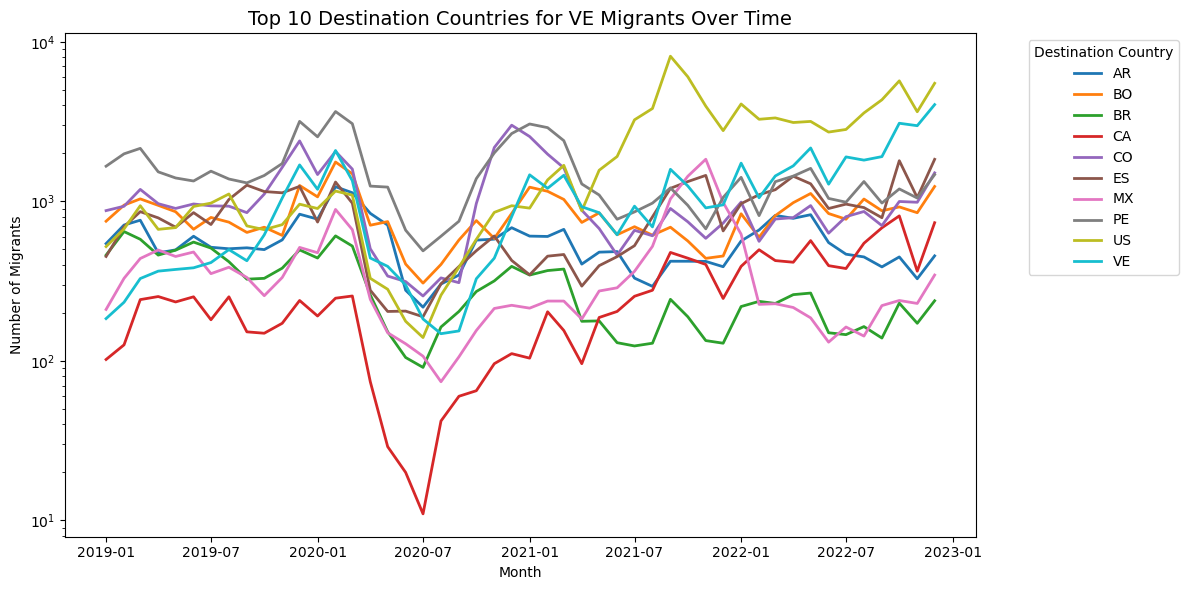

In [6]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_plot,
    x='migration_month',
    y='num_migrants',
    hue=comparison,
    linewidth=2
)

# Check logged result 
plt.yscale('log')

plt.title('Top 10 Destination Countries for VE Migrants Over Time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Migrants')
plt.legend(title='Destination Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
fig = px.line(
    df_plot,
    x='migration_month',
    y='num_migrants',
    color=comparison,
    title='Top 10 Destination Countries for Ukrainian Migrants Over Time',
    labels={
        'migration_month': 'Month',
        'num_migrants': 'Number of Migrants',
        'country': 'Destination/Origin Country'
    },
)

# Add vertical line + annotation
fig.add_vline(
    x="2021-04-01",
    line_width=2,
    line_dash="dash",
    line_color="red"
)

fig.add_annotation(
    x="2021-04-01",
    y=max(df_plot['num_migrants']),  # place near the top of the chart
    text="Ley 21325<br>April 2021",
    showarrow=True,
    arrowhead=2,
    ax=40,  # x offset of annotation text
    ay=-40,  # y offset of annotation text
    font=dict(color="red", size=12),
    align="center"
)

fig.update_layout(
    template='plotly_white',
    legend_title_text='Destination Country',
    xaxis_title='Migration Month',
    yaxis_title='Number of Migrants',
    hovermode='x unified'
)

fig.show()

## Top migrants countries

In [9]:
# Sum migrants 
country_totals = (
    df_plot.groupby(comparison)['num_migrants']
    .sum()
    .reset_index()
    .sort_values(by='num_migrants', ascending=False)
)

# Display
country_totals

,country_to,num_migrants
8,US,98022
7,PE,72761
9,VE,52225
4,CO,49897
5,ES,39562
1,BO,39486
0,AR,26928
6,MX,18562
2,BR,14148
3,CA,12807


# Data preparation

In [10]:
mi_from = mi_from.copy()  

# Create integer month index for regressions (months since earliest month in data)
mi_from = mi_from.sort_values('migration_month')
mi_from['month_id'] = ((mi_from['migration_month'].dt.year - mi_from['migration_month'].dt.year.min()) * 12 +
                       (mi_from['migration_month'].dt.month - mi_from['migration_month'].dt.month.min()))

# Filter data before the policy date and compute top10
pre_policy = mi_from[mi_from['migration_month'] < policy_baci]

# Subset data to top10 countries (you can adjust as desired)
df_top = mi_from[mi_from[comparison].isin(top10_countries)].copy()

# Ensure types
df_top['migration_month'] = pd.to_datetime(df['migration_month'])

df_top

,country_from,country_to,migration_month,num_migrants,year,month,month_id
290540,CL,MX,2019-01-01,210,2019,1,0
291164,CL,PE,2019-01-01,1659,2019,1,0
285404,CL,AR,2019-01-01,543,2019,1,0
287420,CL,ES,2019-01-01,451,2019,1,0
286748,CL,CO,2019-01-01,874,2019,1,0
...,...,...,...,...,...,...,...
286459,CL,CA,2022-12-01,734,2022,12,47
293371,CL,VE,2022-12-01,4035,2022,12,47
293179,CL,US,2022-12-01,5488,2022,12,47
291211,CL,PE,2022-12-01,1469,2022,12,47


In [11]:
# Basic checks
print(df_top.shape)
print(df_top.dtypes)
print(df_top[['country_from',comparison]].nunique())
print("Date range:", df['migration_month'].min(), "to", df_top['migration_month'].max())

(480, 7)
country_from               object
country_to                 object
migration_month    datetime64[ns]
num_migrants                int64
year                        int32
month                       int32
month_id                    int32
dtype: object
country_from     1
country_to      10
dtype: int64
Date range: 2019-01-01 00:00:00 to 2022-12-01 00:00:00


In [12]:
# Check for duplicates (same origin, dest, month)
dups = df_top[df_top.duplicated(['country_from','country_to','migration_month'], keep=False)]
print("Duplicates:", len(dups))

Duplicates: 0


In [13]:
# Add log outcome (log1p handles zeros)
df_top['ln_migrants'] = np.log1p(df['num_migrants'])

# Create a continuous month index if useful
df_top = df_top.sort_values('migration_month')
min_month = df_top['migration_month'].min()
df_top['month_id'] = ((df_top['migration_month'].dt.year - min_month.year) * 12 +
                  (df_top['migration_month'].dt.month - min_month.month))
df_top

,country_from,country_to,migration_month,num_migrants,year,month,month_id,ln_migrants
290540,CL,MX,2019-01-01,210,2019,1,0,5.351858
291164,CL,PE,2019-01-01,1659,2019,1,0,7.414573
285404,CL,AR,2019-01-01,543,2019,1,0,6.298949
287420,CL,ES,2019-01-01,451,2019,1,0,6.113682
286748,CL,CO,2019-01-01,874,2019,1,0,6.774224
...,...,...,...,...,...,...,...,...
286123,CL,BO,2022-12-01,1238,2022,12,47,7.122060
286459,CL,CA,2022-12-01,734,2022,12,47,6.599870
293371,CL,VE,2022-12-01,4035,2022,12,47,8.303009
293179,CL,US,2022-12-01,5488,2022,12,47,8.610501


### Coverage diagnostics
Check data coverage and completeness for each destination country.

In [14]:
# Coverage by destination (diagnostic)
cov = df_top.groupby(comparison).agg(
    n_obs=('migration_month','size'),
    min_month=('migration_month','min'),
    max_month=('migration_month','max'),
    n_zeros=('num_migrants', lambda s: int((s==0).sum()))
).sort_values('n_obs', ascending=False)
# print("Coverage top destinations:\n", cov.head(10))
cov

,n_obs,min_month,max_month,n_zeros
country_to,,,,
AR,48,2019-01-01,2022-12-01,0
BO,48,2019-01-01,2022-12-01,0
BR,48,2019-01-01,2022-12-01,0
CA,48,2019-01-01,2022-12-01,0
CO,48,2019-01-01,2022-12-01,0
ES,48,2019-01-01,2022-12-01,0
MX,48,2019-01-01,2022-12-01,0
PE,48,2019-01-01,2022-12-01,0
US,48,2019-01-01,2022-12-01,0


### Before/After indicator
Label observations as pre-policy (0) or post-policy (1) and summarize coverage.  
    
Creates a binary variable `after`:
- `1` if the observation is after the policy month (`policy_baci`)
- `0` otherwise

In [15]:
# How many months pre and post policy we have
df_top['after'] = (df_top['migration_month'] >= policy_baci).astype(int)
summary = df_top.groupby(comparison)['after'].agg(['sum', 'count'])
# print(summary.head(30))
summary

,sum,count
country_to,,
AR,21,48
BO,21,48
BR,21,48
CA,21,48
CO,21,48
ES,21,48
MX,21,48
PE,21,48
US,21,48


### Pivot into wide panel (time × destinations)
prepare pivot: 
- rows = months, 
- columns = destination 
- Cells = log of migrant counts (`ln_migrants`)

In [16]:
pivot_ln = df_top.pivot(index='migration_month', columns=comparison, values='ln_migrants').sort_index()

# ensure a continuous monthly index from min to max (month starts)
all_months = pd.date_range(pivot_ln.index.min(), pivot_ln.index.max(), freq='MS')
pivot_ln = pivot_ln.reindex(all_months)
# note: do not blindly fill; we will ffill/ffill per-usage as needed

pivot_ln

country_to,AR,BO,BR,CA,CO,ES,MX,PE,US,VE
2019-01-01,6.298949,6.621406,6.133398,4.634729,6.774224,6.113682,5.351858,7.414573,6.255750,5.220356
2019-02-01,6.566672,6.853299,6.472346,4.844187,6.837333,6.542472,5.799093,7.592870,6.510258,5.455321
2019-03-01,6.635947,6.943122,6.361302,5.493061,7.080026,6.759255,6.084499,7.671827,6.844815,5.796058
2019-04-01,6.165418,6.850126,6.133398,5.537334,6.874198,6.669498,6.206576,7.333023,6.504288,5.902633
2019-05-01,6.208590,6.758095,6.204558,5.459586,6.805723,6.535241,6.113682,7.244942,6.529419,5.926926
2019-06-01,6.405228,6.505784,6.320768,5.533389,6.870053,6.745236,6.177944,7.201171,6.834109,5.950643
2019-07-01,6.246107,6.675823,6.234411,5.204007,6.842683,6.573680,5.866468,7.342779,6.882437,6.025866
2019-08-01,6.224558,6.608001,6.037871,5.533389,6.838405,6.935370,5.958425,7.229839,7.013915,6.212606
2019-09-01,6.238325,6.459904,5.786897,5.030438,6.745236,7.141245,5.811141,7.173958,6.553933,6.052089
2019-10-01,6.212606,6.535241,5.799093,5.010635,7.012115,7.049255,5.549076,7.280697,6.499787,6.424869


In [17]:
# 3) define pre/post masks 
pre_mask = pivot_ln.index < policy_baci
post_mask = pivot_ln.index >= policy_baci

# 4) select candidate donors: require min_pre_months non-missing pre observations
candidate_donors = [c for c in pivot_ln.columns if c != treated_unit] # Excludes the treated country
good_donors = [c for c in candidate_donors if pivot_ln.loc[pre_mask, c].notna().sum() >= min_pre_months]
print(f"Found {len(good_donors)} candidate donors with >= {min_pre_months} pre months")
print(good_donors)

# Require at least a few donors
if len(good_donors) < 4:
    print("WARNING: fewer than 4 good donors. SCM inference will be weak.")

Found 9 candidate donors with >= 12 pre months
['AR', 'BO', 'BR', 'CA', 'CO', 'ES', 'MX', 'PE', 'VE']


# Model construction
Inputs: prepared panel  
Output: synthetic control weights and counterfactual series

## Build predictor matrix for SCM

Purpose:
Compute average outcomes over time “blocks” (e.g., -12 to -1 months before the policy).

How it works:
- Each block is a range of months relative to the policy date (e.g., (-12, -1) = one year before policy).
- For each country’s time series, it calculates the mean log migration in that block.

👉 This reduces noise and captures pre-policy trends or “predictors” of migration levels.

    
Purpose:
Construct the predictor matrix used to find synthetic weights.

What it does:
- For each unit (treated + donors), it stores block means as features.
- These are then combined into a DataFrame (pred_df).

👉 The synthetic control method uses these predictors to find weights that best reproduce the treated unit’s pre-policy pattern.

  

    
Two common choices:
- Use several lag-block averages (e.g., mean in months 1–3, 4–6, 7–12 pre-policy)
- Use the full pre-period vector (each pre-month is a predictor)  

Example: create block averages (recommended for stability).
    

- `pred_df`: the predictor matrix
- `donor_units`: the valid donor pool

## Predictor construction (block averages)

Use block averages of pre-policy periods as predictors.  
(Each block summarizes migration behavior in a given pre-period window.)  
👉 Produces predictor matrix `pred_df`.

In [18]:
# 5) Build predictor matrix using block means relative to policy_baci
def block_mean_for_series(series, start_offset_months, end_offset_months):
    # start_offset_months <= end_offset_months (both negative or zero)
    start_date = policy_baci + pd.DateOffset(months=start_offset_months)
    end_date   = policy_baci + pd.DateOffset(months=end_offset_months)
    mask = (series.index >= start_date) & (series.index <= end_date)
    vals = series.loc[mask].dropna()
    if vals.empty:
        return np.nan
    return vals.mean()

# -- Build predictors for treated + donors
predictors = {}
units_for_pred = [treated_unit] + good_donors
for unit in units_for_pred:
    s = pivot_ln[unit]
    preds = [block_mean_for_series(s, a, b) for (a,b) in blocks]
    predictors[unit] = preds

pred_df = pd.DataFrame.from_dict(
    predictors,
    orient='index',
    columns=[f'block_{i}' for i in range(len(blocks))]
)

# Drop units missing *any* predictor block
pred_df = pred_df.dropna()

pred_df

,block_0,block_1,block_2
US,6.782837,5.514466,6.901191
AR,6.492074,5.979240,6.425535
BO,6.804421,6.210622,6.806304
BR,6.118408,5.033204,5.838711
CA,5.338316,3.520031,4.750800
CO,7.144147,5.815983,7.564728
ES,6.891951,5.535758,6.128536
MX,6.090052,4.841118,5.357110
PE,7.550634,6.659019,7.750739
VE,6.628190,5.504777,6.706467


In [19]:
# Syntax fix: explicit check
if treated_unit not in pred_df.index:
    raise RuntimeError("Treated unit missing predictors - increase pre-period or adjust blocks.")
    
# donors used for optimization
donor_units = [c for c in pred_df.index if c != treated_unit]
print("Donor units used:", donor_units)

Donor units used: ['AR', 'BO', 'BR', 'CA', 'CO', 'ES', 'MX', 'PE', 'VE']


## Solve SCM weights (convex: w >= 0, sum(w)=1) using cvxpy

This constructs weights to match predictor moments. You can also use the entire pre-vector as predictors (less stable), or implement a V matrix to weight predictors.

## Optimisation (weight estimation)

- Solve the convex problem
- Returns synthetic weights `w`

In [20]:
# 6) Solve convex problem to get weights for treated unit
if len(donor_units) == 0:
    raise RuntimeError("No donor units available after predictor filtering.")

X_t = pred_df.loc[treated_unit].values               # shape (P,)
X_d = pred_df.loc[donor_units].values.T              # shape (P, J)

J = X_d.shape[1]
w = cp.Variable(J, nonneg=True)

# Optional small ridge regularizer to stabilize weights (lambda small, e.g. 1e-6).
# Uncomment if you see instability or collinearity issues:
# lam = 1e-6
# objective = cp.Minimize(cp.sum_squares(X_t - X_d @ w) + lam * cp.sum_squares(w))

objective = cp.Minimize(cp.sum_squares(X_t - X_d @ w))
constraints = [cp.sum(w) == 1]
prob = cp.Problem(objective, constraints)

# Try solvers with informative messages
solved = False
succeeded_solver = None
for solver in [cp.OSQP, cp.SCS, cp.ECOS_BB]:
    try:
        prob.solve(solver=solver, warm_start=True, verbose=False)
        if w.value is not None:
            solved = True
            succeeded_solver = solver.__name__ if hasattr(solver, "__name__") else str(solver)
            break
    except Exception as e:
        # keep trying next solver
        continue

if not solved or w.value is None:
    raise RuntimeError("SCM solver failed. Try different solver or change predictors/donor set.")

# Convert to pandas Series with donor index
weights = pd.Series(np.array(w.value).flatten(), index=donor_units)

# Drop tiny weights and renormalize (so weights sum to 1 exactly)
weights = weights[weights > 1e-8].sort_values(ascending=False)
if weights.sum() <= 0:
    raise RuntimeError("All weights dropped as tiny; consider lowering threshold or not dropping.")
weights = weights / weights.sum()

print(f"Solver used: {succeeded_solver}")
print("Top donor weights:\n", weights.head(20))


Solver used: OSQP
Top donor weights:
 CO    0.475415
VE    0.162376
CA    0.136221
PE    0.113188
BR    0.030412
BO    0.025909
AR    0.020193
MX    0.018997
ES    0.017290
dtype: float64


## Synthetic series reconstruction
- Multiply donor matrix by weights → synthetic counterfactual for treated unit.

In [21]:
# 7) Build synthetic series
pivot_filled = pivot_ln.copy().ffill().bfill()

# Align weights to all pivot columns (weights for non-donors -> 0)
weight_vec = weights.reindex(pivot_filled.columns).fillna(0).values

# Optional renormalize to be safe (should already sum to 1)
if weight_vec.sum() != 0:
    weight_vec = weight_vec / weight_vec.sum()

synth_series = pivot_filled.values.dot(weight_vec)      # numpy array aligned with pivot_filled.index
synth = pd.Series(synth_series, index=pivot_filled.index)
synth

2019-01-01    6.231462
2019-02-01    6.385963
2019-03-01    6.663517
2019-04-01    6.532577
2019-05-01    6.479971
2019-06-01    6.525325
2019-07-01    6.485370
2019-08-01    6.545574
2019-09-01    6.389949
2019-10-01    6.581976
2019-11-01    6.899558
2019-12-01    7.315482
2020-01-01    6.952794
2020-02-01    7.331890
2020-03-01    7.103313
2020-04-01    6.020124
2020-05-01    5.654906
2020-06-01    5.406041
2020-07-01    5.097039
2020-08-01    5.416604
2020-09-01    5.492083
2020-10-01    6.273580
2020-11-01    6.807447
2020-12-01    7.122691
2021-01-01    7.149032
2021-02-01    7.087931
2021-03-01    6.966464
2021-04-01    6.413017
2021-05-01    6.365786
2021-06-01    6.090139
2021-07-01    6.369665
2021-08-01    6.319375
2021-09-01    6.789336
2021-10-01    6.614817
2021-11-01    6.388914
2021-12-01    6.457406
2022-01-01    6.831821
2022-02-01    6.431894
2022-03-01    6.682674
2022-04-01    6.732042
2022-05-01    6.912016
2022-06-01    6.494101
2022-07-01    6.658347
2022-08-01 

In [22]:
print("Sum(weights) =", weights.sum())
print("Treated predictors:\n", pred_df.loc[treated_unit])
print("Weighted donor predictors (should be close):\n", (pred_df.loc[weights.index].T @ weights).values.flatten())

Sum(weights) = 0.9999999999999999
Treated predictors:
 block_0    6.782837
block_1    5.514466
block_2    6.901191
Name: US, dtype: float64
Weighted donor predictors (should be close):
 [6.7828366  5.51446599 6.90119083]


# Evaluation and inference
Inputs: treated and synthetic series  
Output: estimated effect, diagnostics, robustness checks

## Fit diagnostics
- Plot treated vs. synthetic series (pre/post).
- Plot “gap” = difference between treated and synthetic.
- Compute RMSPE pre vs. post.

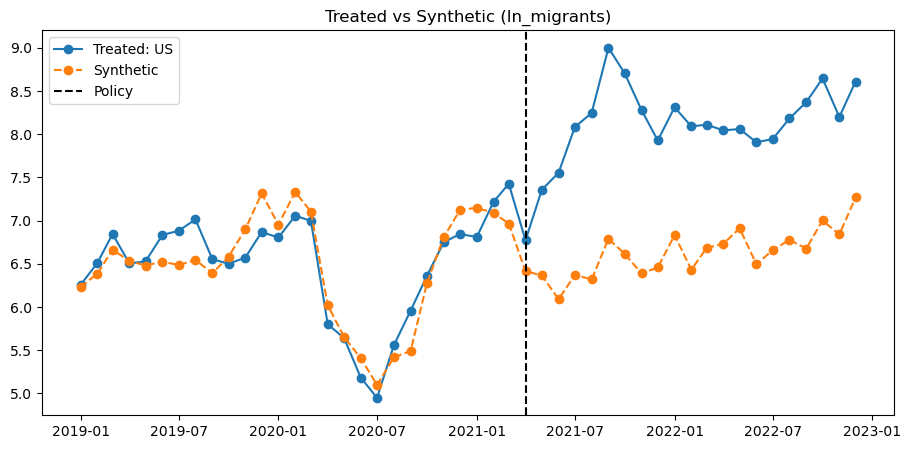

In [23]:
# 8) Plot treated vs synthetic (log space)
plt.figure(figsize=(11,5))
plt.plot(pivot_filled.index, pivot_filled[treated_unit], label=f'Treated: {treated_unit}', marker='o')
plt.plot(synth.index, synth, label='Synthetic', marker='o', linestyle='--')
plt.axvline(policy_baci, color='k', linestyle='--', label='Policy')
plt.legend()
plt.title('Treated vs Synthetic (ln_migrants)')
plt.show()

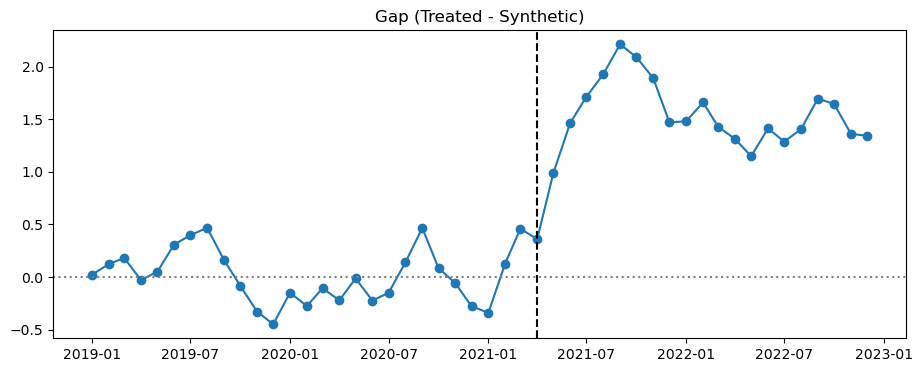

In [24]:
# 9) Gap plot
gap = (pivot_filled[treated_unit] - synth).dropna()
plt.figure(figsize=(11,4))
plt.plot(gap.index, gap, marker='o')
plt.axvline(policy_baci, color='k', linestyle='--')
plt.axhline(0, color='gray', linestyle=':')
plt.title('Gap (Treated - Synthetic)')
plt.show()

In [25]:
# RMSPE helper (robust to mask shapes)
def rmspe_arr(true_arr, pred_arr, mask_bool):
    true_arr = np.asarray(true_arr, dtype=float)
    pred_arr = np.asarray(pred_arr, dtype=float)
    mask = np.asarray(mask_bool, dtype=bool)
    if mask.shape[0] != true_arr.shape[0]:
        # try to align by index length, but fail loudly if shapes mismatch
        raise ValueError("Mask length does not match series length.")
    valid = mask & (~np.isnan(true_arr)) & (~np.isnan(pred_arr))
    if valid.sum() == 0:
        return np.nan
    d = true_arr[valid] - pred_arr[valid]
    return np.sqrt(np.mean(d**2))

# Ensure masks aligned to pivot_filled index
pre_mask_bool = (pivot_filled.index < policy_baci)
post_mask_bool = (pivot_filled.index >= policy_baci)
true = pivot_filled[treated_unit].to_numpy()
pred = synth.to_numpy()

r_pre = rmspe_arr(true, pred, pre_mask_bool)
r_post = rmspe_arr(true, pred, post_mask_bool)
ratio = r_post / (r_pre + 1e-12)
print(f"RMSPE pre={r_pre:.4f}, post={r_post:.4f}, ratio={ratio:.4f}")

RMSPE pre=0.2557, post=1.5398, ratio=6.0211


## Effect quantification
- The average post-policy gap = estimated treatment effect (in logs, % etc.).
- RMSPE ratio quantifies post-policy divergence relative to pre-fit quality.

In [26]:
post_index = pivot_filled.index >= policy_baci
ln_true_post = pivot_filled.loc[post_index, treated_unit].to_numpy(dtype=float)
ln_synth_post = synth.loc[post_index].to_numpy(dtype=float)
# drop any months where either is nan
valid_mask = (~np.isnan(ln_true_post)) & (~np.isnan(ln_synth_post))
ln_true_post = ln_true_post[valid_mask]
ln_synth_post = ln_synth_post[valid_mask]
ln_gap_post = ln_true_post - ln_synth_post

n_post_months = len(ln_gap_post)
avg_ln_gap = np.nanmean(ln_gap_post) if n_post_months>0 else np.nan
se_ln_gap = np.nanstd(ln_gap_post, ddof=1) / np.sqrt(n_post_months) if n_post_months>1 else np.nan
t_stat = avg_ln_gap / (se_ln_gap + 1e-12) if not np.isnan(se_ln_gap) else np.nan
p_val_t = 2 * (1 - stats.t.cdf(abs(t_stat), df=max(0, n_post_months - 1))) if not np.isnan(t_stat) else np.nan

# convert to levels safely
levels_true_post = np.exp(ln_true_post)
levels_synth_post = np.exp(ln_synth_post)

# Guard against division by zero in monthly percent changes
with np.errstate(divide='ignore', invalid='ignore'):
    pct_changes_each_month = (levels_true_post - levels_synth_post) / levels_synth_post
    pct_changes_each_month = pct_changes_each_month[~np.isnan(pct_changes_each_month) & ~np.isinf(pct_changes_each_month)]

pct_geometric = (np.exp(avg_ln_gap) - 1) * 100 if not np.isnan(avg_ln_gap) else np.nan
pct_arithmetic = np.nanmean(pct_changes_each_month) * 100 if pct_changes_each_month.size>0 else np.nan

cumulative_effect_level = np.nansum(levels_true_post - levels_synth_post)
cumulative_pct = (cumulative_effect_level / np.nansum(levels_synth_post)) * 100 if np.nansum(levels_synth_post)!=0 else np.nan

print("=== Effect quantification (post-policy period) ===")
print(f"Post months considered (non-missing pairs): {n_post_months}")
print(f"Avg log-gap (treated - synthetic): {avg_ln_gap:.4f}")
print(f"SE(log-gap): {se_ln_gap:.4f}, t-stat = {t_stat:.3f}, approx p-value (two-sided) = {p_val_t:.3f}")
print(f"Percent change (geometric, exp(mean(log gap))-1): {pct_geometric:.1f}%")
print(f"Percent change (arithmetic mean of monthly level % changes): {pct_arithmetic:.1f}%")
print(f"Cumulative absolute effect (levels): {cumulative_effect_level:.1f} migrants")
print(f"Cumulative percent change (cum true vs. cum synthetic): {cumulative_pct:.1f}%")


=== Effect quantification (post-policy period) ===
Post months considered (non-missing pairs): 21
Avg log-gap (treated - synthetic): 1.4902
SE(log-gap): 0.0866, t-stat = 17.199, approx p-value (two-sided) = 0.000
Percent change (geometric, exp(mean(log gap))-1): 343.8%
Percent change (arithmetic mean of monthly level % changes): 375.8%
Cumulative absolute effect (levels): 61067.9 migrants
Cumulative percent change (cum true vs. cum synthetic): 372.2%


## Placebo-in-space tests
- Re-run SCM for each donor as “treated.”
- Compare RMSPE ratios across all → empirical p-value.

In [27]:
placebo_results = []
attempted = 0
used = 0
for donor in donor_units:
    pool = [d for d in donor_units if d != donor]
    # minimal donors to fit
    if len(pool) < 3:
        continue
    if donor not in pred_df.index:
        continue
    attempted += 1
    X_td = pred_df.loc[donor].values
    X_don = pred_df.loc[pool].values.T
    M = X_don.shape[1]
    w_p = cp.Variable(M, nonneg=True)
    probp = cp.Problem(cp.Minimize(cp.sum_squares(X_td - X_don @ w_p)), [cp.sum(w_p) == 1])
    try:
        probp.solve(solver=cp.OSQP, warm_start=True, verbose=False)
    except Exception:
        try:
            probp.solve(solver=cp.SCS, warm_start=True, verbose=False)
        except Exception:
            continue
    if w_p.value is None:
        continue
    wp = np.nan_to_num(np.array(w_p.value).flatten(), nan=0.0)
    if wp.sum() <= 0:
        continue
    wp = wp / wp.sum()
    # synth for donor - ensure pool ordering matches wp
    pool_filled_df = pivot_filled[pool]  # columns are in same order as `pool`
    synth_p = pool_filled_df.values.dot(wp)
    true_p = pivot_filled[donor].values
    r_pre_p = rmspe_arr(true_p, synth_p, pre_mask_bool)
    r_post_p = rmspe_arr(true_p, synth_p, post_mask_bool)
    ratio_p = np.nan if np.isnan(r_pre_p) else (r_post_p / (r_pre_p + 1e-12))
    placebo_results.append({
        'donor': donor,
        'r_pre': float(r_pre_p) if not np.isnan(r_pre_p) else np.nan,
        'r_post': float(r_post_p) if not np.isnan(r_post_p) else np.nan,
        'ratio': float(ratio_p) if not np.isnan(ratio_p) else np.nan
    })
    used += 1

placebo_df = pd.DataFrame(placebo_results).sort_values('ratio', ascending=False).reset_index(drop=True)
print(f"Placebos attempted: {attempted}, successful placebos: {used}")
print("Placebo summary (top rows):")
# print(placebo_df.head(10))
placebo_df

Placebos attempted: 9, successful placebos: 9
Placebo summary (top rows):


,donor,r_pre,r_post,ratio
0,BR,0.220913,1.041726,4.715552
1,MX,0.280851,0.953431,3.394796
2,ES,0.383565,0.789588,2.058548
3,BO,0.165768,0.332954,2.008557
4,VE,0.497528,0.987171,1.984154
5,AR,0.213061,0.385184,1.807858
6,CO,0.328157,0.487236,1.484766
7,CA,0.948448,0.912519,0.962118
8,PE,0.565789,0.379426,0.670615


Placebo p-value (fraction >= treated ratio): 0.0


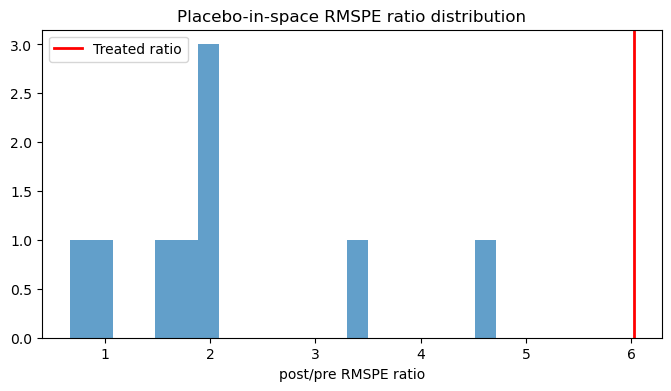

In [28]:
# p-value: fraction of placebos with ratio >= treated ratio
if not placebo_df.empty and not np.isnan(ratio):
    p_val = np.nanmean(placebo_df['ratio'].values >= ratio)
else:
    p_val = np.nan
print("Placebo p-value (fraction >= treated ratio):", p_val)

# Plot placebo distribution
plt.figure(figsize=(8,4))
vals = placebo_df['ratio'].dropna()
plt.hist(vals, bins=20, alpha=0.7)
plt.axvline(ratio, color='red', linewidth=2, label='Treated ratio')
plt.xlabel('post/pre RMSPE ratio')
plt.title('Placebo-in-space RMSPE ratio distribution')
plt.legend()
plt.show()

# Plot for report checks

## Pre policy

Pre-policy months: n = 27
mean_gap_pre = 0.0112
sd_gap_pre   = 0.2604
one-sample t-test (H0: mean=0): t = 0.223, p = 0.825
standardized mean (mean / sd) = 0.043
year_month   gap_pre
   2019-01  0.024288
   2019-02  0.124295
   2019-03  0.181298
   2019-04 -0.028288
   2019-05  0.049447
   2019-06  0.308784
   2019-07  0.397068
   2019-08  0.468341
   2019-09  0.163985
   2019-10 -0.082189
   2019-11 -0.327275
   2019-12 -0.448549
   2020-01 -0.148179
   2020-02 -0.275715
   2020-03 -0.105717
   2020-04 -0.221031
   2020-05 -0.012999
   2020-06 -0.224258
   2020-07 -0.148279
   2020-08  0.140225
   2020-09  0.466342
   2020-10  0.085994
   2020-11 -0.058687
   2020-12 -0.277875
   2021-01 -0.338890
   2021-02  0.128778
   2021-03  0.460680


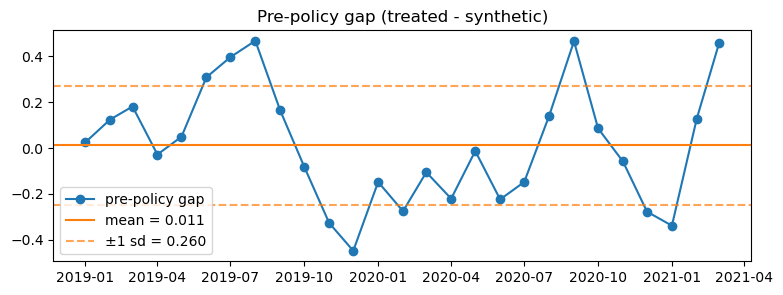

In [29]:
# 1) compute gap = treated - synthetic (in same units used for SCM: here ln_migrants)
gap = (pivot_filled[treated_unit] - synth).copy()

# 2) select pre-policy months
pre_mask = gap.index < policy_baci
gap_pre = gap.loc[pre_mask].dropna()

# 3) basic summary stats: mean and sd (sample std: ddof=1)
mean_gap_pre = gap_pre.mean()
sd_gap_pre   = gap_pre.std(ddof=1)
n_pre = gap_pre.shape[0]

print(f"Pre-policy months: n = {n_pre}")
print(f"mean_gap_pre = {mean_gap_pre:.4f}")
print(f"sd_gap_pre   = {sd_gap_pre:.4f}")

# 4) t-test of mean == 0 (one-sample t-test)
tstat, pval = stats.ttest_1samp(gap_pre, popmean=0.0, nan_policy='omit')
print(f"one-sample t-test (H0: mean=0): t = {tstat:.3f}, p = {pval:.3f}")

# 5) standardized mean (Cohen's d-ish): mean / sd
std_mean = mean_gap_pre / (sd_gap_pre + 1e-12)
print(f"standardized mean (mean / sd) = {std_mean:.3f}")

# 6) show monthly pre-gap table for visual inspection
pre_table = pd.DataFrame({'gap_pre': gap_pre})
pre_table['year_month'] = pre_table.index.to_period('M').astype(str)
print(pre_table.reset_index(drop=False).loc[:, ['year_month','gap_pre']].to_string(index=False))

# 7) small plot: pre-gap series with mean ± 1 sd
plt.figure(figsize=(9,3))
plt.plot(gap_pre.index, gap_pre.values, marker='o', label='pre-policy gap')
plt.axhline(mean_gap_pre, color='C1', linestyle='-', label=f'mean = {mean_gap_pre:.3f}')
plt.axhline(mean_gap_pre + sd_gap_pre, color='C1', linestyle='--', alpha=0.7)
plt.axhline(mean_gap_pre - sd_gap_pre, color='C1', linestyle='--', alpha=0.7, label=f'±1 sd = {sd_gap_pre:.3f}')
plt.title('Pre-policy gap (treated - synthetic)')
plt.legend()
plt.show()

In [30]:
# # gap is your pd.Series (treated - synth) indexed by date; policy_baci is pd.Timestamp
# import statsmodels.api as sm
pre_gap = gap[gap.index < policy_baci].dropna()
t_idx = np.arange(len(pre_gap))  # simple linear time index
X = sm.add_constant(t_idx)
res = sm.OLS(pre_gap.values, X).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.020
Method:                 Least Squares   F-statistic:                    0.4860
Date:                Thu, 30 Oct 2025   Prob (F-statistic):              0.492
Time:                        20:15:33   Log-Likelihood:                -1.2077
No. Observations:                  27   AIC:                             6.415
Df Residuals:                      25   BIC:                             9.007
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0701      0.098      0.711      0.4

In [31]:
rmspe_pre = np.sqrt(np.nanmean(pre_gap.values**2))
print("RMSPE_pre:", rmspe_pre)

RMSPE_pre: 0.25573130936468075


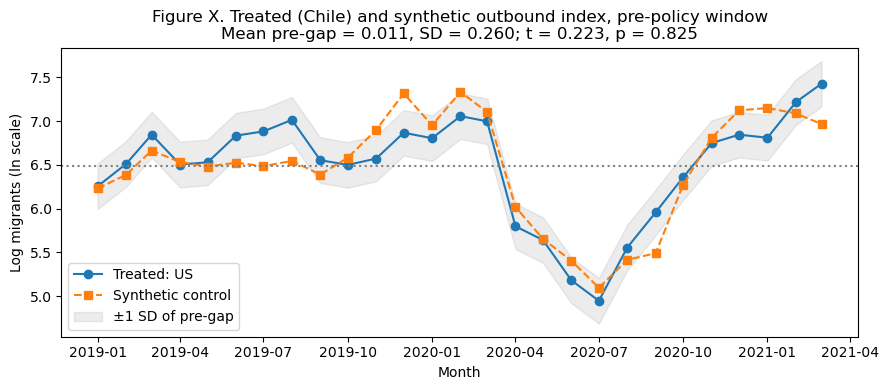

In [32]:
# --- subset to pre-policy window ---
pre_mask = gap.index < policy_baci
pre_period = pivot_filled.loc[pre_mask, [treated_unit]].copy()
pre_period['Synthetic'] = synth.loc[pre_mask]

# --- Plot ---
plt.figure(figsize=(9,4))
plt.plot(pre_period.index, pre_period[treated_unit], label=f'Treated: {treated_unit}', color='C0', marker='o')
plt.plot(pre_period.index, pre_period['Synthetic'], label='Synthetic control', color='C1', marker='s', linestyle='--')

# SD shading relative to treated (for visualization)
plt.fill_between(
    pre_period.index,
    pre_period[treated_unit] - sd_gap_pre,
    pre_period[treated_unit] + sd_gap_pre,
    color='gray', alpha=0.15, label='±1 SD of pre-gap'
)

plt.axhline(pre_period[treated_unit].mean(), color='gray', linestyle=':')
plt.title(
    "Figure X. Treated (Chile) and synthetic outbound index, pre-policy window\n"
    f"Mean pre-gap = {mean_gap_pre:.3f}, SD = {sd_gap_pre:.3f}; t = 0.223, p = 0.825"
)
plt.xlabel("Month")
plt.ylabel("Log migrants (ln scale)")
plt.legend()
plt.tight_layout()
plt.show()

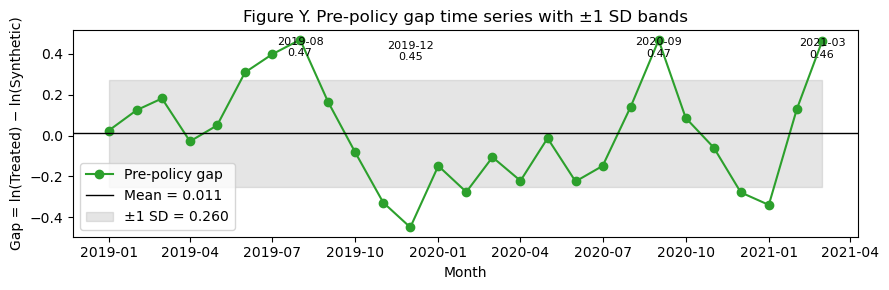

In [33]:
# --- compute gap and find largest absolute gaps ---
gap_pre = gap.loc[pre_mask].dropna()
top_abs = gap_pre.abs().sort_values(ascending=False).head(4)  # label top 4 absolute gaps

plt.figure(figsize=(9,3))
plt.plot(gap_pre.index, gap_pre.values, color='C2', marker='o', label='Pre-policy gap')

# mean line and ±1 SD band
plt.axhline(mean_gap_pre, color='black', linewidth=1, linestyle='-', label=f'Mean = {mean_gap_pre:.3f}')
plt.fill_between(
    gap_pre.index,
    mean_gap_pre - sd_gap_pre,
    mean_gap_pre + sd_gap_pre,
    color='gray', alpha=0.2, label=f'±1 SD = {sd_gap_pre:.3f}'
)

# label largest absolute deviations
for dt, val in top_abs.items():
    plt.annotate(
        f"{dt.strftime('%Y-%m')}\n{val:.2f}",
        xy=(dt, val),
        xytext=(0, 8 if val < 0 else -12),
        textcoords="offset points",
        ha='center', fontsize=8, color='black',
        arrowprops=dict(arrowstyle='-', lw=0.5, color='gray')
    )

plt.title("Figure Y. Pre-policy gap time series with ±1 SD bands")
plt.xlabel("Month")
plt.ylabel("Gap = ln(Treated) − ln(Synthetic)")

# 👇 place legend in lower-left corner
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

## Post policy

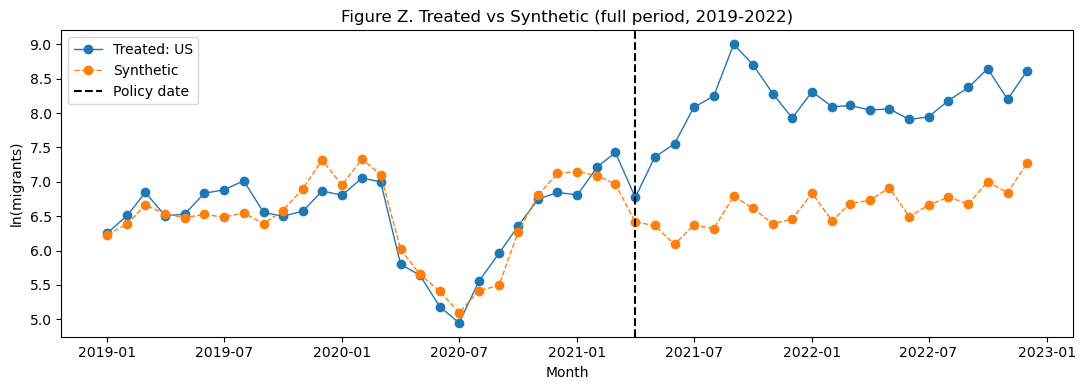

In [34]:
# 1) Figure Z: Treated vs Synthetic (full period) with vertical policy line
plt.figure(figsize=(11,4))
plt.plot(pivot_filled.index, pivot_filled[treated_unit], label=f'Treated: {treated_unit}',  marker='o', linewidth=1)  #  marker='o',
plt.plot(synth.index, synth, label='Synthetic', linestyle='--', marker='o', linewidth=1)  #  marker='s',
plt.axvline(policy_baci, color='k', linestyle='--', label='Policy date')  
plt.title("Figure Z. Treated vs Synthetic (full period, 2019-2022)")
plt.xlabel("Month")
plt.ylabel("ln(migrants)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

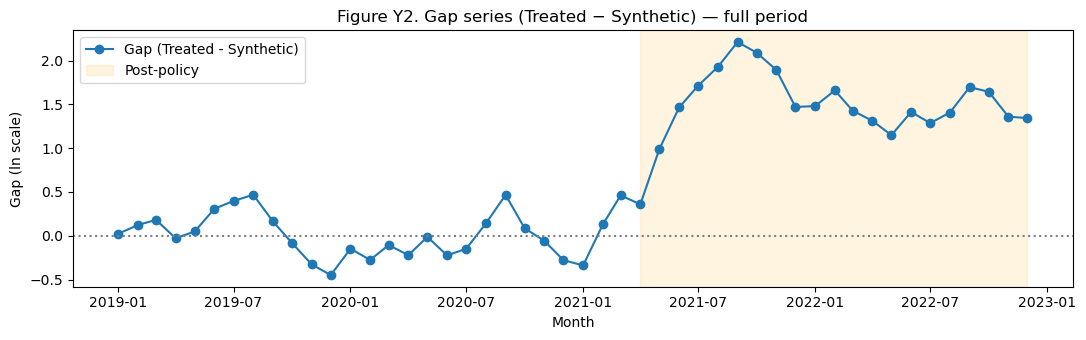

In [35]:
# 2) Figure Y2: Gap series full period with post-policy shading
gap_full = gap.copy()  # treated - synthetic
plt.figure(figsize=(11,3.5))
plt.plot(gap_full.index, gap_full.values, marker='o', label='Gap (Treated - Synthetic)')
# shade post-policy
plt.axvspan(policy_baci, gap_full.index.max(), color='orange', alpha=0.12, label='Post-policy')
plt.axhline(0, color='gray', linestyle=':')
plt.title("Figure Y2. Gap series (Treated − Synthetic) — full period")
plt.xlabel("Month")
plt.ylabel("Gap (ln scale)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [36]:
# 3) Compute Table X2 metrics (post-period)
pre_mask = gap_full.index < policy_baci
post_mask = gap_full.index >= policy_baci
gap_post = gap_full.loc[post_mask].dropna()

mean_post_gap = float(gap_post.mean())
sd_post_gap   = float(gap_post.std(ddof=1))
# RMSPE_post: sqrt(mean(gap^2)) on post
rmspe_post = float(np.sqrt(np.nanmean(gap_post.values**2)))

# If you have r_pre from earlier, compute ratio; otherwise compute pre RMSPE here:
if 'r_pre' in globals():
    rmspe_ratio = r_post / (r_pre + 1e-12)
else:
    gap_pre = gap_full.loc[pre_mask].dropna()
    r_pre = float(np.sqrt(np.nanmean(gap_pre.values**2)))
    rmspe_ratio = rmspe_post / (r_pre + 1e-12)

# OLS "after" coef on simple treated - mean(donors) diff (you earlier used that)
# Build df_diff with column y and after dummy
df_diff = pd.DataFrame({'month': gap_full.index, 'y': gap_full.values})
df_diff['after'] = (df_diff['month'] >= policy_baci).astype(int)

ols_mod = smf.ols('y ~ after', data=df_diff).fit()
# HAC robust SE (Newey-West) with 6 lags like earlier
# ols_mod: the original fitted OLS (statsmodels)
ols_hac = ols_mod.get_robustcov_results(cov_type='HAC', maxlags=6)

# find the integer index of the 'after' parameter
param_names = ols_mod.params.index.tolist()
idx_after = param_names.index('after')

after_coef = ols_mod.params['after']
after_se_hac = ols_hac.bse[idx_after]    # use integer index
after_p = ols_hac.pvalues[idx_after]

print("after coef:", after_coef, "HAC se:", after_se_hac, "p:", after_p)

after coef: 1.4790585189367658 HAC se: 0.12747348978818995 p: 2.92708339045514e-15


In [37]:
pct = (np.exp(after_coef) - 1) * 100
print(f"≈ {pct:.0f}% increase relative to the counterfactual")

≈ 339% increase relative to the counterfactual


In [38]:
# Placebo p-values: raw fraction and conservative Abadie-style
if 'placebo_df' in globals() and ('ratio' in placebo_df.columns):
    raw_p = (placebo_df['ratio'] >= ratio).mean() if not np.isnan(ratio) else np.nan
    # conservative: rank of treated among (treated + placebos) -> r/(J+1)
    # rank = 1 + number of placebos with > treated_ratio
    if not np.isnan(ratio):
        rank = 1 + (placebo_df['ratio'] > ratio).sum()
        cons_p = rank / (len(placebo_df) + 1)
    else:
        cons_p = np.nan
else:
    raw_p = np.nan
    cons_p = np.nan

# Build table
table = pd.DataFrame({
    'Metric': ['Mean post-gap', 'SD post-gap', 'RMSPE_post', 'RMSPE ratio', 'OLS "after" coef (HAC SE)', 'Placebo p-value (raw)', 'Placebo p-value (conservative)'],
    'Value': [
        f"{mean_post_gap:.3f}",
        f"{sd_post_gap:.3f}",
        f"{rmspe_post:.4f}",
        f"{rmspe_ratio:.2f}",
        f"{after_coef:.3f} ({after_se_hac:.3f}), p={after_p:.3f}",
        f"{raw_p if not np.isnan(raw_p) else 'NA'}",
        f"{cons_p if not np.isnan(cons_p) else 'NA'}"
    ],
    'Description': [
        'Treated − synthetic (ln) average over post period',
        'SD of treated − synthetic (post)',
        'Root mean squared prediction error (post)',
        'r_post / r_pre',
        'OLS estimate on gap (after dummy); HAC robust SE (6 lags)',
        'Fraction of placebos with ratio >= treated ratio',
        'Conservative rank-based p-value = rank/(J+1)'
    ]
})
print("\nTable X2 — Post-policy diagnostics")
# print(table.to_string(index=False))

table


Table X2 — Post-policy diagnostics


,Metric,Value,Description
0,Mean post-gap,1.490,Treated − synthetic (ln) average over post period
1,SD post-gap,0.397,SD of treated − synthetic (post)
2,RMSPE_post,1.5398,Root mean squared prediction error (post)
3,RMSPE ratio,6.02,r_post / r_pre
4,"OLS ""after"" coef (HAC SE)","1.479 (0.127), p=0.000",OLS estimate on gap (after dummy); HAC robust ...
5,Placebo p-value (raw),0.0,Fraction of placebos with ratio >= treated ratio
6,Placebo p-value (conservative),0.1,Conservative rank-based p-value = rank/(J+1)


# Robustness / Alternative specifications

## Simple before–after regression on treated – donor mean

What it does: estimates a simple `y ~ after` where `y = ln_treated − ln_mean(donors)`. Use HAC standard errors to account for serial correlation.  
                                                                                                                          
**Notes**:
- Interpret coefficient on after as average log-level shift (comparable to SCM avg log-gap).
- HAC with maxlags=6 is fine for monthly data; you can compute lag selection (e.g., floor(4*(T/100)^(2/9))) but 6 is reasonable.

Newey-West / OLS on difference series (sensitivity)  
You already ran OLS with HAC and found after highly significant. Check sensitivity to HAC lag length and report multiple lags (3, 6, 12).

In [39]:
# ---------- 4.1 Simple before-after regression: treated - donor mean (log space) ----------
# Purpose: quick sanity check. Coefficient on `after` should be similar sign/rough magnitude to SCM avg post gap.
diff = pivot_filled[treated_unit] - pivot_filled[good_donors].mean(axis=1)
df_diff = pd.DataFrame({'migration_month': diff.index, 'y': diff.values}).dropna()
df_diff['after'] = (df_diff['migration_month'] >= policy_baci).astype(int)

mod_ols = smf.ols('y ~ after', data=df_diff).fit()
print("=== OLS before-after (treated - donor mean) ===")
print(mod_ols.summary())
print("\nHAC robust SEs (maxlags=6):")
print(mod_ols.get_robustcov_results(cov_type='HAC', maxlags=6).summary())

# Optional: show HAC for other lags (3,6,12)
for lag in [3,6,12]:
    print(f"\nHAC maxlags={lag}:")
    print(mod_ols.get_robustcov_results(cov_type='HAC', maxlags=lag).summary())

=== OLS before-after (treated - donor mean) ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     284.3
Date:                Thu, 30 Oct 2025   Prob (F-statistic):           2.56e-21
Time:                        20:15:43   Log-Likelihood:                -9.5008
No. Observations:                  48   AIC:                             23.00
Df Residuals:                      46   BIC:                             26.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inte

## Donor-level RMSPE diagnostics / reuse placebo results
What it does: show how donors fit in pre-period; helps contextualize treated result

In [40]:
# ---------- 4.2 Donor-level RMSPE diagnostics (reuse placebo results when available) ----------
# Purpose: show how donors fit pre/post and where treated sits among placebos.
if 'placebo_df' in globals() and 'r_pre' in placebo_df.columns:
    print("\n=== Placebo summary (donor-level RMSPEs) ===")
    display(placebo_df[['donor','r_pre','r_post','ratio']].head(20))
else:
    # fallback (cruder): donor vs mean-of-others pre-RMSPE
    pre_mask_bool = (pivot_filled.index < policy_baci).to_numpy()
    rmspe_donors = {}
    for donor in donor_units:
        others = [d for d in donor_units if d != donor]
        if len(others) == 0:
            continue
        true = pivot_filled[donor].to_numpy()
        pred = pivot_filled[others].mean(axis=1).to_numpy()
        rmspe_donors[donor] = rmspe_arr(true, pred, pre_mask_bool)
    print("\nFallback donor pre-RMSPE (donor vs mean-of-others):")
    display(pd.Series(rmspe_donors).sort_values().head(20))



=== Placebo summary (donor-level RMSPEs) ===


,donor,r_pre,r_post,ratio
0,BR,0.220913,1.041726,4.715552
1,MX,0.280851,0.953431,3.394796
2,ES,0.383565,0.789588,2.058548
3,BO,0.165768,0.332954,2.008557
4,VE,0.497528,0.987171,1.984154
5,AR,0.213061,0.385184,1.807858
6,CO,0.328157,0.487236,1.484766
7,CA,0.948448,0.912519,0.962118
8,PE,0.565789,0.379426,0.670615


## Time-series diagnostics on SCM gap (ADF, ACF, PACF)
What it does: test stationarity and show autocorrelation to decide whether to model levels or differences.

**Interpretation rules of thumb**:
- If ADF p-value < 0.05, gap is stationary → you can model levels.
- If p-value large (> 0.1), gap likely non-stationary → consider differencing before SARIMAX.

ADF statistic: -0.998691803758179 p-value: 0.7537411366154154


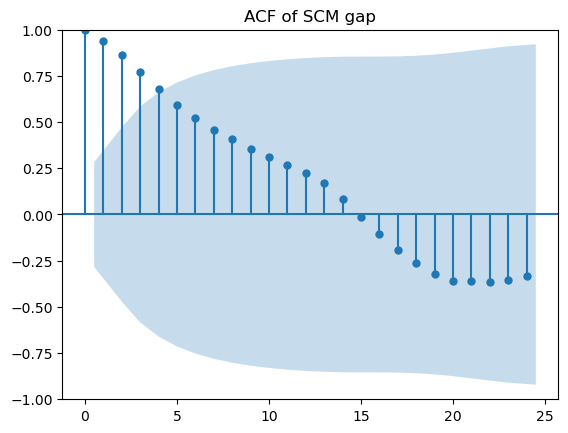

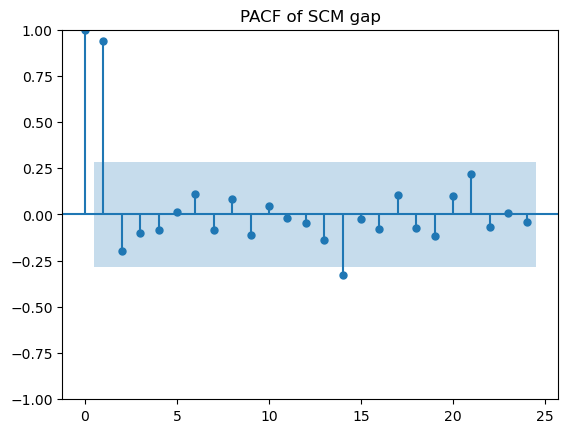

In [41]:
# ---------- 4.3 Time-series diagnostics on SCM gap (ADF, ACF, PACF) ----------
# Purpose: check stationarity and serial structure of the SCM gap (treated - synthetic).
gap = (pivot_filled[treated_unit] - synth).dropna()
if gap.empty:
    raise RuntimeError("SCM gap is empty — check pivot_filled and synth alignment.")

adf_res = adfuller(gap)
adf_stat, adf_p = adf_res[0], adf_res[1]
# print(f"\n=== ADF on SCM gap: statistic={adf_stat:.4f}, p-value={adf_p:.4f} ===")
print("ADF statistic:", adf_res[0], "p-value:", adf_p)

# ACF & PACF of gap (raw)
sm.graphics.tsa.plot_acf(gap, lags=24); plt.title('ACF of SCM gap'); plt.show()
sm.graphics.tsa.plot_pacf(gap, lags=24); plt.title('PACF of SCM gap'); plt.show()


## SARIMAX structural break test with policy dummy
**What it does**: models the gap as an AR process with a post-policy dummy to test for a structural level shift while controlling for serial correlation.  
**What to report from SARIMAX**:
- Coefficient on the exog (post dummy), its SE and p-value — the structural-break estimate controlling for AR(1).
- Whether residuals appear uncorrelated (ACF of residuals) — if residuals still have serial correlation, increase AR order or include MA terms.

In [42]:
# ---------- 4.4 SARIMAX structural-break test (gap as endog; post dummy as exog) ----------
# Purpose: control for autocorrelation and test for a level shift at policy date.
post_dummy = pd.Series((pivot_filled.index >= policy_baci).astype(int), index=pivot_filled.index)

if adf_p > 0.1:
    # non-stationary gap -> model first difference (interpretation: effect on changes)
    print("\nGap non-stationary by ADF (p>0.1) → modelling first difference")
    endog = gap.diff().dropna()
    exog = post_dummy.reindex(endog.index).fillna(0)
else:
    print("\nGap stationary by ADF (p<=0.1) → modelling gap in levels")
    endog = gap
    exog = post_dummy.reindex(endog.index).fillna(0)



Gap non-stationary by ADF (p>0.1) → modelling first difference


In [43]:
# Fit SARIMAX(1,0,0) with exog; change order if residuals suggest it
model = sm.tsa.SARIMAX(endog, exog=exog, order=(1,0,0), enforce_stationarity=False)
res = model.fit(disp=False)
print("\n=== SARIMAX results (gap / diff) ===")
print(res.summary())


=== SARIMAX results (gap / diff) ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   47
Model:               SARIMAX(1, 0, 0)   Log Likelihood                   0.593
Date:                Thu, 30 Oct 2025   AIC                              4.814
Time:                        20:15:47   BIC                             10.300
Sample:                    02-01-2019   HQIC                             6.870
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0              0.0336      0.066      0.508      0.612      -0.096       0.163
ar.L1          0.2147      0.160      1.341      0.180      -0.099       0.528
sigma2        


Model params:
 0         0.033590
ar.L1     0.214690
sigma2    0.057058
dtype: float64


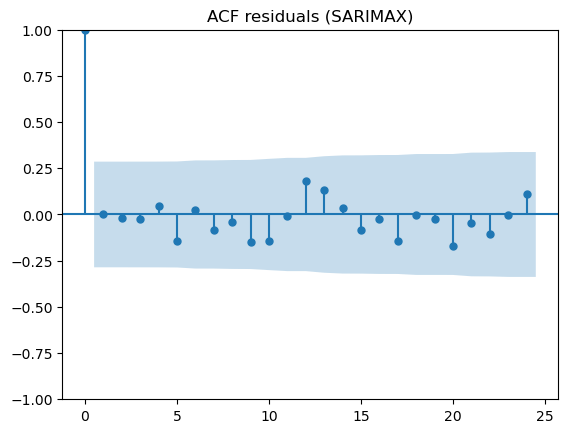

In [44]:
exog_name = []
for name in res.params.index:
    if isinstance(name, str) and (name.lower().startswith('exog') or name == 'exog'):
        exog_name.append(name)
if exog_name:
    name = exog_name[0]
    print(f"\nPost-dummy coef = {res.params[name]:.4f}, SE = {res.bse[name]:.4f}, p = {res.pvalues[name]:.3f}")
else:
    print("\nModel params:\n", res.params)

# Residual diagnostics
sm.graphics.tsa.plot_acf(res.resid.dropna(), lags=24); plt.title('ACF residuals (SARIMAX)'); plt.show()

Check stationarity / unit root and autocorrelation (ADF, ACF)  
The SARIMAX AR≈0.997 suggests near-unit-root. Test with Augmented Dickey–Fuller (ADF) and plot ACF/PACF.

还是不知道这个是干啥的

If ADF fails to reject nonstationarity (p > 0.05), you should difference the series (or include an integration term d=1 in SARIMAX) before estimating intervention effects, or use models that allow for trends.

**Check stationarity / unit root and autocorrelation (ADF, ACF)**  
The SARIMAX AR≈0.997 suggests near-unit-root. Test with Augmented Dickey–Fuller (ADF) and plot ACF/PACF.

## Additional descriptive checks (counts, top months)

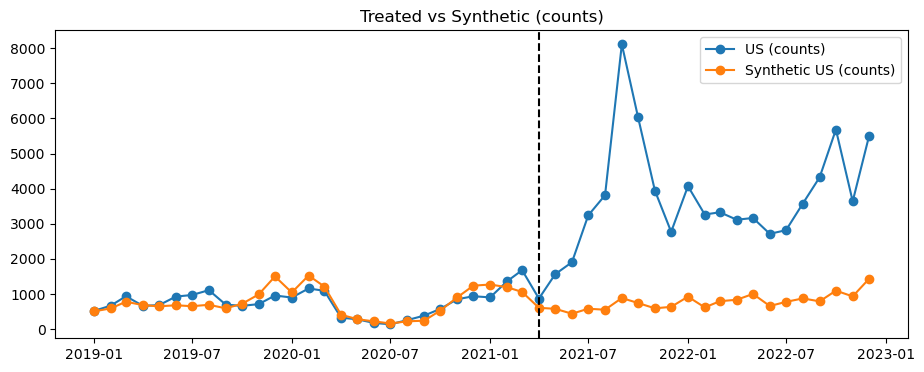


Top post months by absolute count gap:


2021-09-01    7223.676827
2021-10-01    5283.931809
2022-10-01    4586.597476
2022-12-01    4055.673769
2022-09-01    3532.337400
2021-11-01    3351.789950
2021-08-01    3259.774073
2022-01-01    3145.123066
2022-11-01    2706.447592
2022-08-01    2702.014343
dtype: float64


Pre mean (treated counts): 761.8, Post mean: 3688.2
Synthetic pre mean: 762.6, synthetic post mean: 780.2
Post minus synthetic as % of synthetic pre-mean: 381.3%


In [45]:
# ---------- 4.5 Additional descriptive checks (counts, top months) ----------
# Purpose: practical, policy-oriented magnitudes in levels (counts).
# Convert ln back to counts: pivot_ln is ln(series + 1) or ln(series)? Adjust accordingly.
# I assume pivot_ln = ln(1 + counts) OR ln(counts). Replace np.expm1 with np.exp if pivot_ln = ln(counts).
use_expm1 = True   # set to False if pivot_ln contains ln(counts) not ln(1+counts)
if use_expm1:
    inv = np.expm1
else:
    inv = np.exp

plt.figure(figsize=(11,4))
plt.plot(pivot_filled.index, inv(pivot_ln[treated_unit]), label=f'{treated_unit} (counts)', marker='o')
plt.plot(synth.index, inv(synth), label=f'Synthetic {treated_unit} (counts)', marker='o')
plt.axvline(policy_baci, linestyle='--', color='k')
plt.title('Treated vs Synthetic (counts)')
plt.legend()
plt.show()

# Top post-months by absolute (count) gap
post_mask = pivot_filled.index >= policy_baci
gap_counts = (inv(pivot_ln[treated_unit]) - inv(synth)).loc[post_mask]
print("\nTop post months by absolute count gap:")
display(gap_counts.sort_values(ascending=False).head(10))

# Simple percent change / pre-vs-post means in counts (document baseline)
pre_mask = pivot_filled.index < policy_baci
pre_mean_count = inv(pivot_ln[treated_unit].loc[pre_mask]).mean()
post_mean_count = inv(pivot_ln[treated_unit].loc[post_mask]).mean()
synt_pre_mean = inv(synth.loc[pre_mask]).mean()
synt_post_mean = inv(synth.loc[post_mask]).mean()

pct_change = (post_mean_count - synt_post_mean) / (synt_pre_mean if synt_pre_mean != 0 else np.nan) * 100
print(f"\nPre mean (treated counts): {pre_mean_count:.1f}, Post mean: {post_mean_count:.1f}")
print(f"Synthetic pre mean: {synt_pre_mean:.1f}, synthetic post mean: {synt_post_mean:.1f}")
print(f"Post minus synthetic as % of synthetic pre-mean: {pct_change:.1f}%")

**Check whether the post effect is driven by one or a few months (influence)**  
Large single-month spikes (e.g., December 2022 with 5488 migrants) can drive big post-RMSPE. Plot the raw counts and inspect outliers; run leave-one-month influence.

## Leave-one-donor-out (stability of weights & affected outcome)

Your synthetic is heavily weighted on ES (61%); if ES had its own shock, that could bias results. Recompute SCM excluding the top donor(s) and observe the effect.

In [46]:
# Re-estimate SCM excluding Spain (ES)
donors_minus_ES = [d for d in donor_units if d != 'ES']
# (re-run your cvxpy optimization with donor pool donors_minus_ES)
# then recompute synth, RMSPE and ratio. Compare coefficients/results.

If effect disappears when excluding one donor, you must report that and explore reasons (spillover on that donor or poor donor choice).

Report everything transparently in paper

- Show the pre-fit synthetic plot and pre-RMSPE (0.1875).
- Show the treated vs synthetic series with policy line and gap plot.
- Report weights table (you have ES 61%, PE 18%, CO 12%, etc.). Discuss whether those donors are plausible.
- Report RMSPE post/pre ratio (~7.99) and placebo p-value (0.0).
- Show sensitivity: leave-one-donor-out, alternative predictors, models (Newey-West, SARIMAX with d=0 and d=1), and results excluding influential months (if any).
- Discuss AR(1) ≈ 0.997 concern — you tried SARIMAX and found near unit-root; explain how you dealt with it (difference or other).

 Concrete immediate checklist for you to run now (in this order)
- Influence check: identify whether the post-gap is driven by 1–2 months.
- Leave-one-donor-out SCM: re-run without ES, PE, CO individually and record post/pre ratios.
- ADF test on the diff series; if nonstationary, difference the series and re-fit SARIMAX.
- Re-run SARIMAX with d=1 and/or model differenced gap; report coefficient on intervention appropriately.
- HAC sensitivity: rerun OLS Newey-West with lags 3/6/12 and report.
- Robustness table: show SCM baseline, SCM w/o ES, NW OLS on diff, SARIMAX(d=1), and count/level models.

If you want I can produce a single notebook cell that performs steps 1–3 (influence, leave-one-donor-out SCM, ADF + ACF/PACF plots), and prints a compact results table so you can inspect stability quickly. Say “yes — make the diagnostic cell” and I’ll put that together.